In [45]:
#imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

import joblib, json, os

sns.set(style = "whitegrid")
RANDOM_STATE = 42

In [33]:
#load the preprocessed dataset from 01_eda_preprocessing
df = pd.read_csv("data/interim/df_preprocessed.csv")
print(df.shape)
df.head()

(30000, 38)


,id,limit_bal,gender,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,log_bill_amt3,log_bill_amt4,log_bill_amt5,log_bill_amt6,log_pay_amt1,log_pay_amt2,log_pay_amt3,log_pay_amt4,log_pay_amt5,log_pay_amt6
0,1,20000,Female,University,Married,24,2,2,-1,-1,...,6.536692,0.000000,0.000000,0.000000,0.000000,6.536692,0.000000,0.000000,0.000000,0.000000
1,2,120000,Female,University,Single,26,-1,2,0,0,...,7.894691,8.093462,8.147867,8.090096,0.000000,6.908755,6.908755,6.908755,0.000000,7.601402
2,3,90000,Female,University,Single,34,0,0,0,0,...,9.514880,9.570250,9.612400,9.651816,7.325808,7.313887,6.908755,6.908755,6.908755,8.517393
3,4,50000,Female,University,Married,37,0,0,0,0,...,10.805517,10.251147,10.273671,10.293771,7.601402,7.610853,7.090910,7.003974,6.975414,6.908755
4,5,50000,Male,University,Married,57,-1,0,-1,0,...,10.486708,9.949464,9.859901,9.859118,7.601402,10.510041,9.210440,9.105091,6.536692,6.522093


In [34]:
#features and target
y = df["default"]
X = df.drop(columns=["default", "id"], errors="ignore")

#identify feature types
cat_cols = [
    "gender", "education", "marriage",
    "pay_1", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"
]

num_cols = [c for c in X.columns if c not in cat_cols]

In [35]:
#train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Default rate train:", y_train.mean().round(3), "| test:", y_test.mean().round(3))

Train: (24000, 36) Test: (6000, 36)
Default rate train: 0.221 | test: 0.221


In [36]:
#preprocessing:
# - standardize numeric features
# - one-hot encode categoricals 
pre = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown = "ignore", sparse_output = False), cat_cols),
    ],
    remainder = "drop"
)

Baseline models

In [37]:
#logistic regression (interpretable baseline)

logit = Pipeline(steps = [
    ("pre", pre),
    ("clf", LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced",   
        random_state = RANDOM_STATE
    ))
])

logit.fit(X_train, y_train)
proba_logit = logit.predict_proba(X_test)[:, 1]
pred_logit  = (proba_logit >= 0.5).astype(int)

roc_logit = roc_auc_score(y_test, proba_logit)
pr_logit  = average_precision_score(y_test, proba_logit)

print(f"LogReg ROC-AUC: {roc_logit:.3f} | PR-AUC: {pr_logit:.3f}")
print(classification_report(y_test, pred_logit, digits = 3))

LogReg ROC-AUC: 0.771 | PR-AUC: 0.532
              precision    recall  f1-score   support

           0      0.877     0.800     0.837      4673
           1      0.462     0.605     0.524      1327

    accuracy                          0.757      6000
   macro avg      0.670     0.703     0.680      6000
weighted avg      0.785     0.757     0.768      6000



In [38]:
#random forest (non-linear baseline)

rf = Pipeline(steps = [
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators = 400,
        max_depth = None,
        min_samples_leaf = 2,
        class_weight = "balanced",
        random_state = RANDOM_STATE,
        n_jobs = -1
    ))
])

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)

roc_rf = roc_auc_score(y_test, proba_rf)
pr_rf  = average_precision_score(y_test, proba_rf)

print(f"RF ROC-AUC: {roc_rf:.3f} | PR-AUC: {pr_rf:.3f}")
print(classification_report(y_test, pred_rf, digits = 3))

RF ROC-AUC: 0.767 | PR-AUC: 0.545
              precision    recall  f1-score   support

           0      0.850     0.920     0.884      4673
           1      0.604     0.428     0.501      1327

    accuracy                          0.811      6000
   macro avg      0.727     0.674     0.692      6000
weighted avg      0.795     0.811     0.799      6000



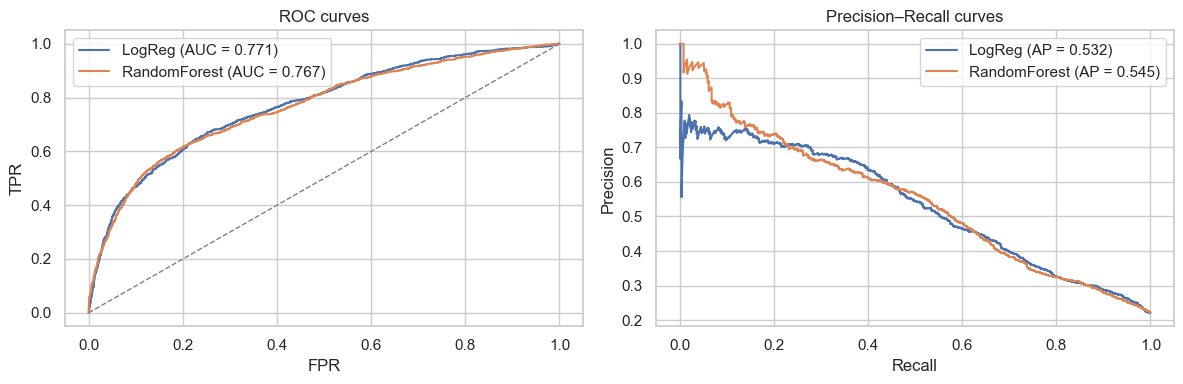

In [39]:
#curves: ROC & Precision–Recall

def plot_curves(y_true, scores_dict):
    plt.figure(figsize = (12, 4))
    
    #ROC
    plt.subplot(1, 2, 1)
    for name, s in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, s)
        auc = roc_auc_score(y_true, s)
        plt.plot(fpr, tpr, label = f"{name} (AUC = {auc:.3f})")
    plt.plot([0, 1],[0, 1],"--", lw = 1, color = "gray")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("ROC curves")
    plt.legend()

    #PR
    plt.subplot(1, 2, 2)
    for name, s in scores_dict.items():
        p, r, _ = precision_recall_curve(y_true, s)
        ap = average_precision_score(y_true, s)
        plt.plot(r, p, label = f"{name} (AP = {ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall curves")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_curves(y_test, {"LogReg": proba_logit, "RandomForest": proba_rf})

In [40]:
#KS statistic

def ks_statistic(y_true, y_score):
    #sort by score descending
    data = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score", ascending = False)
    data["cum_good"] = (1 - data["y"]).cumsum() / ((1 - data["y"]).sum())
    data["cum_bad"]  = (data["y"]).cumsum() / (data["y"].sum())
    ks = (data["cum_bad"] - data["cum_good"]).abs().max()
    return ks

ks_logit = ks_statistic(y_test, proba_logit)
ks_rf    = ks_statistic(y_test, proba_rf)
print(f"KS (LogReg): {ks_logit:.3f}")
print(f"KS (RandomForest): {ks_rf:.3f}")

KS (LogReg): 0.419
KS (RandomForest): 0.417


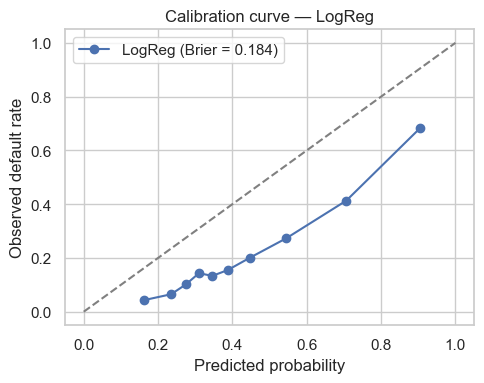

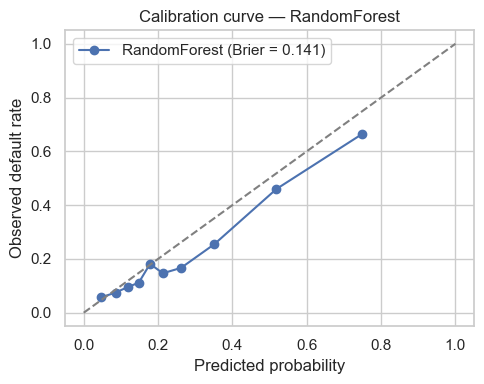

Brier LogReg: 0.184
Brier RF: 0.141


In [41]:
#calibration (Brier + reliability curve)

def plot_calibration(y_true, y_score, name):
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins = 10, strategy = "quantile")
    brier = brier_score_loss(y_true, y_score)
    
    plt.figure(figsize = (5,4))
    plt.plot(prob_pred, prob_true, marker = "o", label = f"{name} (Brier = {brier:.3f})")
    plt.plot([0, 1], [0, 1], "--", color = "gray")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed default rate")
    plt.title(f"Calibration curve — {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return brier

brier_logit = plot_calibration(y_test, proba_logit, "LogReg")
brier_rf    = plot_calibration(y_test, proba_rf, "RandomForest")
print("Brier LogReg:", round(brier_logit, 3))
print("Brier RF:", round(brier_rf, 3))

In [42]:
#threshold tuning

def find_threshold(y_true, y_score, target = "f1", min_precision = 0.8):
    best_t, best_v = 0.5, -1
    for t in np.linspace(0.05, 0.95, 91):
        pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        prec = tp/(tp + fp + 1e-9); rec = tp/(tp + fn + 1e-9)
        if target == "f1":
            v = 2*prec*rec/(prec + rec + 1e-9)
        elif target == "recall_at_precision":
            v = rec if prec >= min_precision else -1
        else:
            v = 0
        if v > best_v:
            best_v, best_t = v, t
    return best_t, best_v

t_logit, f1_logit = find_threshold(y_test, proba_logit, target = "f1")
t_rf, f1_rf       = find_threshold(y_test, proba_rf, target = "f1")

print(f"Best F1 (LogReg): {f1_logit:.3f} at threshold = {t_logit:.2f}")
print(f"Best F1 (RF):     {f1_rf:.3f} at threshold = {t_rf:.2f}")

Best F1 (LogReg): 0.528 at threshold = 0.57
Best F1 (RF):     0.538 at threshold = 0.36


In [43]:
#PSI (Population Stability Index: train vs test)

def psi(expected, actual, n_bins = 10):
    expected = np.array(expected)
    actual = np.array(actual)
    bins = np.linspace(0, 1, n_bins + 1)
    e_hist, _ = np.histogram(expected, bins = bins)
    a_hist, _ = np.histogram(actual,   bins = bins)
    
    e_perc = e_hist / (e_hist.sum() + 1e-9)
    a_perc = a_hist / (a_hist.sum() + 1e-9)
    
    psi_vals = (a_perc - e_perc) * np.log((a_perc + 1e-9)/(e_perc + 1e-9))
    return psi_vals.sum()

#get out-of-sample scores on train & test using chosen model
proba_rf_train = rf.predict_proba(X_train)[:, 1]
psi_rf = psi(proba_rf_train, proba_rf)
print(f"PSI (RF train → test): {psi_rf:.3f}")

PSI (RF train → test): 0.461


C:\Users\пк\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


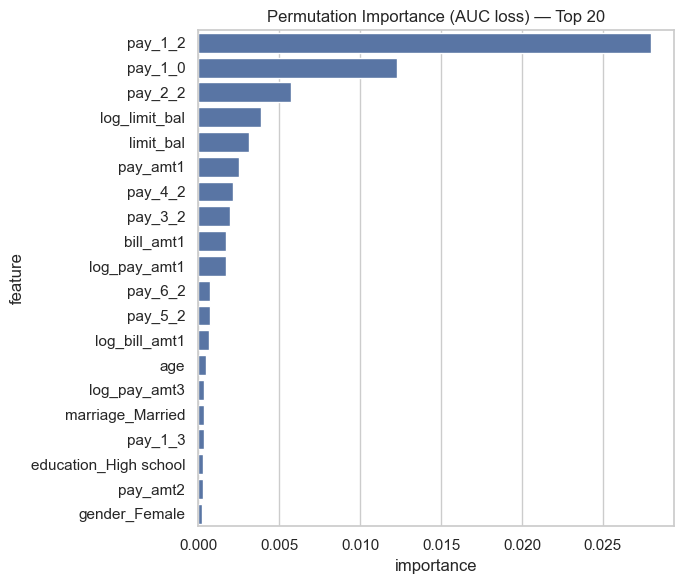

In [44]:
#feature importance (permutation, using RF)

#use transformed space and rf classifier for more granular importance
Xt_test = rf.named_steps["pre"].transform(X_test)
clf_rf  = rf.named_steps["clf"]

#build feature names from preprocessing
ohe = pre.named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
feat_names = num_cols + cat_names

perm = permutation_importance(
    clf_rf, Xt_test, y_test,
    n_repeats = 10, random_state = RANDOM_STATE,
    scoring = "roc_auc", n_jobs = -1
)

pi = (pd.DataFrame({"feature": feat_names, "importance": perm.importances_mean})
        .sort_values("importance", ascending = False)
        .head(20))

plt.figure(figsize = (7, 6))
sns.barplot(data = pi, x = "importance", y = "feature")
plt.title("Permutation Importance (AUC loss) — Top 20")
plt.tight_layout()
plt.show()

In [49]:
#save best model + metadata

os.makedirs("models/artifacts", exist_ok = True)

#choose best model
best_model = rf
best_name  = "RandomForest"

joblib.dump(best_model, "models/artifacts/credit_model.joblib")

meta = {
    "model_name": best_name,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "threshold": 0.36,
    "metrics": {
        "roc_auc": float(roc_rf),
        "pr_auc":  float(pr_rf),
        "ks":      float(ks_statistic(y_test, proba_rf)),
        "brier":   float(brier_score_loss(y_test, proba_rf)),
        "psi_train_test": float(psi_rf)
    },
}

with open("models/artifacts/metadata.json", "w", encoding = "utf-8") as f:
    json.dump(meta, f, indent = 2)

print("Saved best model + metadata into models/artifacts/")

Saved best model + metadata into models/artifacts/
